In [1]:
import numpy as np
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)

In [ ]:
os.getcwd()

'/Users/saranthaworn/Downloads/EC683 Week 5'

In [ ]:
df = pd.read_csv('file_out2.csv')
df = df.drop('Unnamed: 0', axis=1)
df['Price'] = (df['TotalSales']-df['Discount'])/df['Quantity']
df['percent_discount'] = df['Discount']/(df['TotalSales'])
df['Sales_Amount_after_discount'] = df['TotalSales'] - df['Discount']
df = df.fillna(0)
df['rate'] = np.linspace(0.1,1.5, df.shape[0])
df['percent_discount'] = df['percent_discount']*df['rate']
# Clean data for Models 
df['YYYY'] = pd.to_datetime(df['Date']).dt.year
df['MM'] = pd.to_datetime(df['Date']).dt.month
df['DD'] = pd.to_datetime(df['Date']).dt.day
df['weekday'] = pd.to_datetime(df['Date']).dt.weekday # 0 : Mon , 6 : Sun
df

,InvoiceID,Date,ProductID,TotalSales,Discount,CustomerID,Quantity,Price,percent_discount,Sales_Amount_after_discount,rate,YYYY,MM,DD,weekday
0,328,2019-12-27,1684,796.610169,143.389831,185,4,163.305085,0.018000,653.220338,0.100000,2019,12,27,4
1,329,2019-12-27,524,355.932203,64.067797,185,2,145.932203,0.018009,291.864406,0.100048,2019,12,27,4
2,330,2019-12-27,192,901.694915,162.305085,230,4,184.847458,0.018017,739.389830,0.100096,2019,12,27,4
3,330,2019-12-27,218,182.754237,32.895763,230,1,149.858474,0.018026,149.858474,0.100144,2019,12,27,4
4,330,2019-12-27,247,780.101695,140.418305,230,4,159.920847,0.018035,639.683390,0.100192,2019,12,27,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29098,11092,2023-01-13,1644,6573.000000,1183.140000,269,1,5389.860000,0.269965,5389.860000,1.499808,2023,1,13,4
29099,11093,2023-01-13,352,5179.728814,932.351186,250,4,1061.844407,0.269974,4247.377628,1.499856,2023,1,13,4
29100,11094,2023-01-13,683,7741.423729,1393.456271,415,4,1586.991865,0.269983,6347.967458,1.499904,2023,1,13,4
29101,11095,2023-01-14,1830,3644.067797,655.932203,59,4,747.033899,0.269991,2988.135594,1.499952,2023,1,14,5


In [ ]:
df_grouped = df.groupby(['Date'])[['TotalSales']].sum().astype(int)
df_grouped['day_name'] = pd.to_datetime(df_grouped.index).day_name()
df_grouped['weekday'] = pd.to_datetime(df_grouped.index).weekday
df_grouped['quarter'] = pd.to_datetime(df_grouped.index).quarter
df_grouped['is_working_day'] = np.where(df_grouped['weekday'].isin([5, 6]), 0, 1)
df_grouped['Price'] = df.groupby(['Date'])[['Price']].mean().astype(int)
df_grouped['pct_price_day'] = df_grouped['Price'].pct_change().fillna(0)
df_grouped['scale_price'] = (df.groupby(['Date'])[['Price']].mean() - df.groupby(['Date'])[['Price']].min())/(df.groupby(['Date'])[['Price']].max() - df.groupby(['Date'])[['Price']].min())
df_grouped['scale_price'] = df_grouped['scale_price'].fillna(0)
df_grouped['n_customer_unique'] = df.groupby(['Date'])[['CustomerID']].nunique().astype(int)
df_grouped['n_invoice_unique'] = df.groupby(['Date'])[['InvoiceID']].nunique().astype(int)
df_grouped['n_product_unique'] = df.groupby(['Date'])[['ProductID']].nunique().astype(int)
df_grouped['pct_customer_day'] = df_grouped['n_customer_unique'].pct_change().fillna(0)
df_grouped['pct_invoice_day'] = df_grouped['n_invoice_unique'].pct_change().fillna(0)
df_grouped['pct_product_day'] = df_grouped['n_product_unique'].pct_change().fillna(0)
df_grouped['closing_ratio_invoice_customer'] = df_grouped['n_invoice_unique']/df_grouped['n_customer_unique']
df_grouped['closing_ratio_product_customer'] = df_grouped['n_product_unique']/df_grouped['n_customer_unique']
df_grouped['closing_ratio_product_invoice'] = df_grouped['n_product_unique']/df_grouped['n_invoice_unique']
df = df_grouped.drop('day_name', axis=1)
df

,TotalSales,weekday,quarter,is_working_day,Price,pct_price_day,scale_price,n_customer_unique,n_invoice_unique,n_product_unique,pct_customer_day,pct_invoice_day,pct_product_day,closing_ratio_invoice_customer,closing_ratio_product_customer,closing_ratio_product_invoice
Date,,,,,,,,,,,,,,,,
2019-01-02,26514,2,1,1,241,0.000000,0.160009,20,22,28,0.000000,0.000000,0.000000,1.100000,1.400000,1.272727
2019-01-03,21119,3,1,1,359,0.489627,0.464722,12,17,18,-0.400000,-0.227273,-0.357143,1.416667,1.500000,1.058824
2019-01-04,16807,4,1,1,377,0.050139,0.142462,11,12,14,-0.083333,-0.294118,-0.222222,1.090909,1.272727,1.166667
2019-01-05,15722,5,1,0,242,-0.358090,0.461641,12,12,10,0.090909,0.000000,-0.285714,1.000000,0.833333,0.833333
2019-01-07,38985,0,1,1,396,0.636364,0.232311,18,23,23,0.500000,0.916667,1.300000,1.277778,1.277778,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-21,104084,1,1,1,1142,0.004398,0.238813,13,14,18,-0.277778,-0.333333,-0.217391,1.076923,1.384615,1.285714
2023-03-22,132997,2,1,1,814,-0.287215,0.199514,11,12,18,-0.153846,-0.142857,0.000000,1.090909,1.636364,1.500000
2023-03-23,80991,3,1,1,1719,1.111794,0.334025,7,9,12,-0.363636,-0.250000,-0.333333,1.285714,1.714286,1.333333


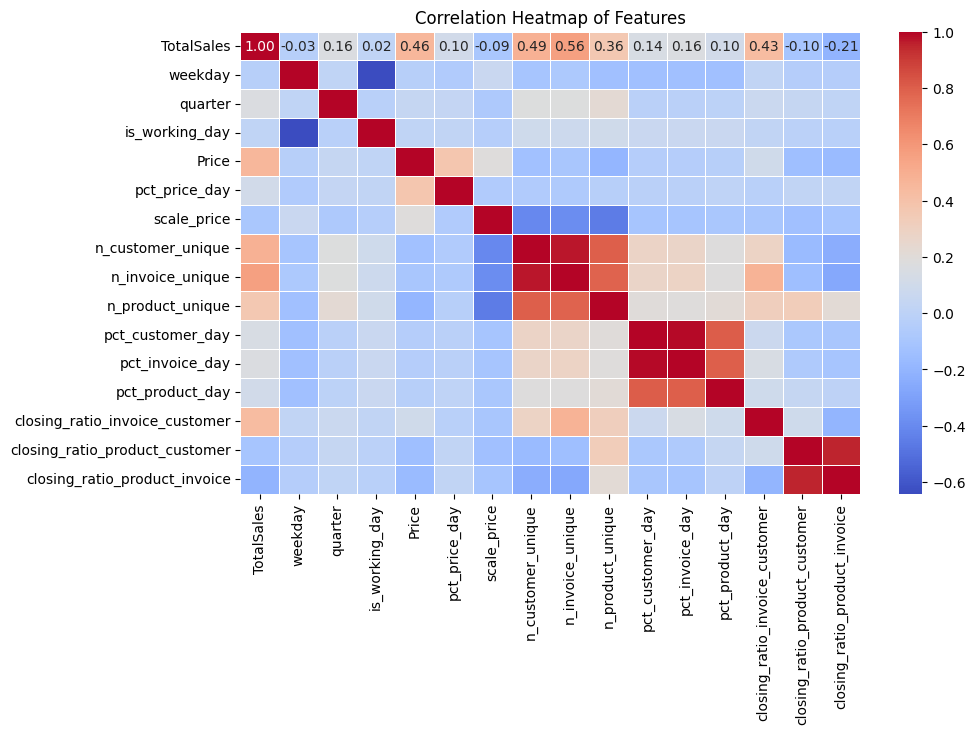

In [ ]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
# ================================
# Step 1: Import Required Libraries
# ================================
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten, Dropout
import ipywidgets as widgets
from IPython.display import display
import datetime

2025-03-08 18:35:44.648075: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
df = df.iloc[:,0:10]
df

,TotalSales,weekday,quarter,is_working_day,Price,pct_price_day,scale_price,n_customer_unique,n_invoice_unique,n_product_unique
Date,,,,,,,,,,
2019-01-02,26514,2,1,1,241,0.000000,0.160009,20,22,28
2019-01-03,21119,3,1,1,359,0.489627,0.464722,12,17,18
2019-01-04,16807,4,1,1,377,0.050139,0.142462,11,12,14
2019-01-05,15722,5,1,0,242,-0.358090,0.461641,12,12,10
2019-01-07,38985,0,1,1,396,0.636364,0.232311,18,23,23
...,...,...,...,...,...,...,...,...,...,...
2023-03-21,104084,1,1,1,1142,0.004398,0.238813,13,14,18
2023-03-22,132997,2,1,1,814,-0.287215,0.199514,11,12,18
2023-03-23,80991,3,1,1,1719,1.111794,0.334025,7,9,12


In [ ]:
df['season'] = np.random.randint(1, 4, df.shape[0])
df['waether'] = np.random.randint(15,33,df.shape[0])
# Define the lower and upper bounds for the random integer generation.
# Convert them to integers if necessary.
low = int(df['n_customer_unique'].min())
high = int(df['n_customer_unique'].mean())

# Generate an array of random integers with the same number of rows as df.
random_values = np.random.randint(low, high, size=df.shape[0])

# Compute the element-wise minimum between the random values and the actual unique customer count.
df['n_customer_female'] = np.minimum(random_values, df['n_customer_unique'])
df['n_customer_male'] = df['n_customer_unique'] - df['n_customer_female']

conditions = [(df['TotalSales'] < df['TotalSales'].mean()), (df['TotalSales'] >= df['TotalSales'].mean())]
choice = [0,1] # 0 for Bad , 1 for good
df['sales_situation'] = np.select(conditions, choice)
df

,TotalSales,weekday,quarter,is_working_day,Price,pct_price_day,scale_price,n_customer_unique,n_invoice_unique,n_product_unique,season,waether,n_customer_female,n_customer_male,sales_situation
Date,,,,,,,,,,,,,,,
2019-01-02,26514,2,1,1,241,0.000000,0.160009,20,22,28,3,31,2,18,0
2019-01-03,21119,3,1,1,359,0.489627,0.464722,12,17,18,1,21,6,6,0
2019-01-04,16807,4,1,1,377,0.050139,0.142462,11,12,14,1,21,8,3,0
2019-01-05,15722,5,1,0,242,-0.358090,0.461641,12,12,10,3,27,9,3,0
2019-01-07,38985,0,1,1,396,0.636364,0.232311,18,23,23,2,24,11,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-21,104084,1,1,1,1142,0.004398,0.238813,13,14,18,2,16,13,0,1
2023-03-22,132997,2,1,1,814,-0.287215,0.199514,11,12,18,1,23,10,1,1
2023-03-23,80991,3,1,1,1719,1.111794,0.334025,7,9,12,2,16,7,0,1


In [ ]:
df.to_csv('WS4.csv')

In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df

,TotalSales,weekday,quarter,is_working_day,Price,pct_price_day,scale_price,n_customer_unique,n_invoice_unique,n_product_unique,season,waether,n_customer_female,n_customer_male,sales_situation
Date,,,,,,,,,,,,,,,
2019-01-02,26514,2,1,1,241,0.000000,0.160009,20,22,28,3,31,2,18,0
2019-01-03,21119,3,1,1,359,0.489627,0.464722,12,17,18,1,21,6,6,0
2019-01-04,16807,4,1,1,377,0.050139,0.142462,11,12,14,1,21,8,3,0
2019-01-05,15722,5,1,0,242,-0.358090,0.461641,12,12,10,3,27,9,3,0
2019-01-07,38985,0,1,1,396,0.636364,0.232311,18,23,23,2,24,11,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-21,104084,1,1,1,1142,0.004398,0.238813,13,14,18,2,16,13,0,1
2023-03-22,132997,2,1,1,814,-0.287215,0.199514,11,12,18,1,23,10,1,1
2023-03-23,80991,3,1,1,1719,1.111794,0.334025,7,9,12,2,16,7,0,1


Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0200   
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0065 
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0078 
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0051 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0061 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0056 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0053 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0044 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0032 
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0037 
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040     
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 
Epoch 16/

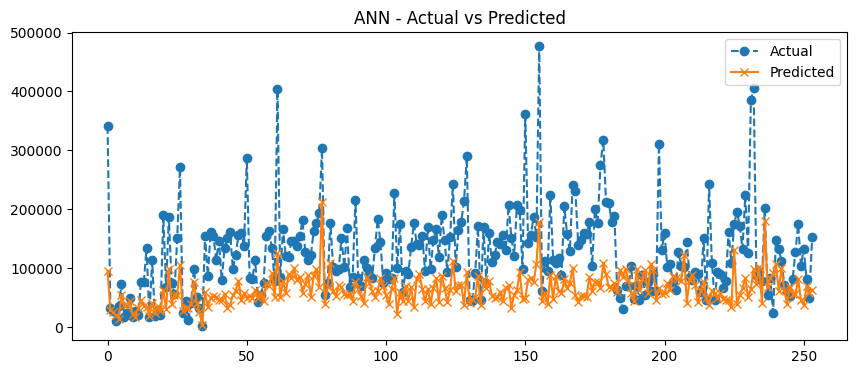

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0167
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0069
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0069
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021   
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016
Epoch 16/50
32/32 ━━━━━━━━

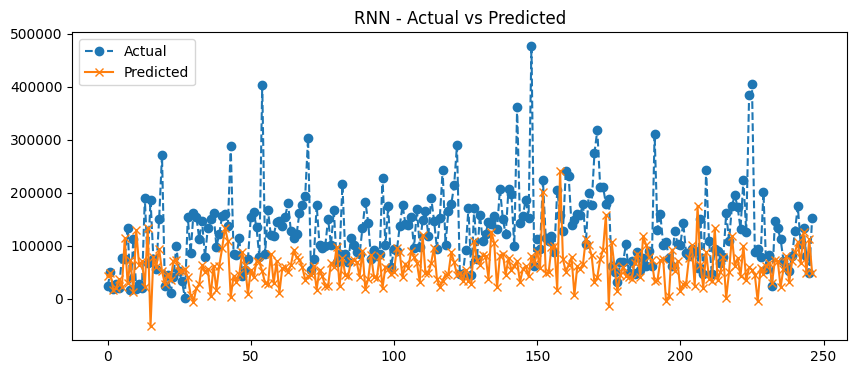

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0359  
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0058 
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052 
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049 
Epoch 16/50
32/

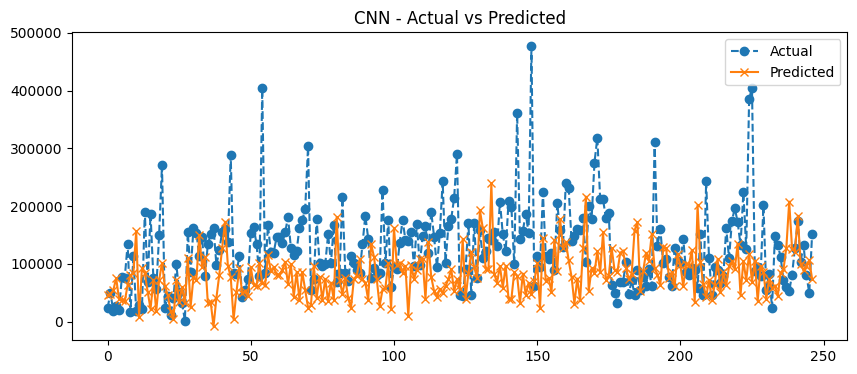

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0076
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0065
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058
Epoch 16/50
32/32 ━━━━━━━━━━━━

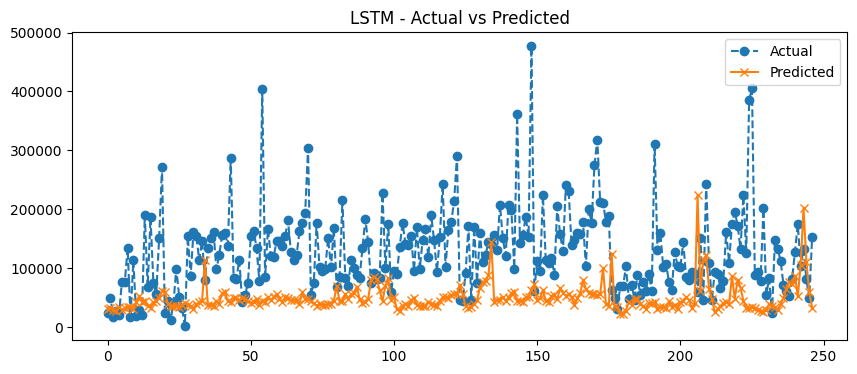


✅ Final Model Evaluation Results:
  Model           MSE           RMSE           MAE   MAPE (%)
0   ANN  7.995139e+09   89415.542261  66634.228737  48.267645
1   RNN  1.087537e+10  104285.052896  77563.216601  72.564892
2   CNN  8.778693e+09   93694.680629  69274.229619  66.999044
3  LSTM  1.160497e+10  107726.348565  83738.058285  70.511147


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("WS4.csv")

# Convert Date column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select numerical features and target
features = ['weekday', 'quarter', 'is_working_day', 'Price', 'pct_price_day', 'scale_price',
            'n_customer_unique', 'n_invoice_unique', 'n_product_unique', 'season', 'waether',
            'n_customer_female', 'n_customer_male']
target = 'TotalSales'

# ✅ Scale both features AND target to improve model performance
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]]).flatten()  # Keep as 1D array

# ✅ Use proper time series split (last 20% for test)
split = int(len(df) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# ✅ Define sequence length for time-series models
sequence_length = 7  # Increased from 2 → 7 for better time dependencies

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i: i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

# Prepare time-series formatted data
X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

# Function to compute MAPE
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to evaluate models with full metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()  # Convert back to original scale
    y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    r2 = r2_score(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    mape = mean_absolute_percentage_error(y_actual, y_pred)

    print(f"\n📌 {model_name} Evaluation:")
    print(f"   ✅ R² Score: {r2:.4f}")
    print(f"   ✅ MSE: {mse:.2f}")
    print(f"   ✅ RMSE: {rmse:.2f}")
    print(f"   ✅ MAE: {mae:.2f}")
    print(f"   ✅ MAPE: {mape:.2f}%")

    plt.figure(figsize=(10, 4))
    plt.plot(y_actual, label="Actual", marker="o", linestyle="dashed")
    plt.plot(y_pred, label="Predicted", marker="x")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.legend()
    plt.show()
    
    return r2, mse, rmse, mae, mape

# 🚀 ANN Model (Tuned)
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
ann_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)
ann_r2, ann_mse, ann_rmse, ann_mae, ann_mape = evaluate_model(ann_model, X_test, y_test, "ANN")

# 🚀 RNN Model (Tuned)
rnn_model = Sequential([
    SimpleRNN(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    SimpleRNN(50, activation='relu'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
rnn_r2, rnn_mse, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(rnn_model, X_test_seq, y_test_seq, "RNN")

# 🚀 CNN Model (Tuned)
cnn_model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(sequence_length, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
cnn_r2, cnn_mse, cnn_rmse, cnn_mae, cnn_mape = evaluate_model(cnn_model, X_test_seq, y_test_seq, "CNN")

# 🚀 LSTM Model (Tuned)
lstm_model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    LSTM(50, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
lstm_r2, lstm_mse, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(lstm_model, X_test_seq, y_test_seq, "LSTM")

# Store Results in DataFrame
results_df = pd.DataFrame({
    "Model": ["ANN", "RNN", "CNN", "LSTM"],
    "MSE": [ann_mse, rnn_mse, cnn_mse, lstm_mse],
    "RMSE": [ann_rmse, rnn_rmse, cnn_rmse, lstm_rmse],
    "MAE": [ann_mae, rnn_mae, cnn_mae, lstm_mae],
    "MAPE (%)": [ann_mape, rnn_mape, cnn_mape, lstm_mape]
})

print("\n✅ Final Model Evaluation Results:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load dataset
df = pd.read_csv("WS4.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select features and target
features = ['weekday', 'quarter', 'is_working_day', 'Price', 'pct_price_day', 'scale_price',
            'n_customer_unique', 'n_invoice_unique', 'n_product_unique', 'season', 'waether',
            'n_customer_female', 'n_customer_male']
target = 'TotalSales'

# Scale features and target
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]]).flatten()

# Train-test split (80% train, 20% test)
split = int(len(df) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# Sequence length for time series models
sequence_length = 14

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i: i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

# ✅ Train Regression Models

# ANN Model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer='adam', loss='mse')
ann_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# RNN Model
rnn_model = Sequential([
    SimpleRNN(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    SimpleRNN(50, activation='relu'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=0)

# CNN Model
cnn_model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(sequence_length, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=0)

# LSTM Model
lstm_model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    LSTM(50, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=0)

# Dictionary to store models
models = {
    "ANN": ann_model,
    "RNN": rnn_model,
    "CNN": cnn_model,
    "LSTM": lstm_model
}

# ✅ Create UI with ipywidgets

# Dropdown for selecting model
model_dropdown = widgets.Dropdown(
    options=["ANN", "RNN", "CNN", "LSTM"],
    value="ANN",
    description="Model:"
)

# Sliders for feature values
sliders = {feature: widgets.FloatSlider(
    min=df[feature].min(),
    max=df[feature].max(),
    step=(df[feature].max() - df[feature].min()) / 100,
    value=df[feature].mean(),
    description=feature[:10],
    continuous_update=False
) for feature in features}

# Button to predict
predict_button = widgets.Button(
    description="Predict Sales",
    button_style='success'
)

# Output area for displaying results
output = widgets.Output()

# Function to predict sales
def predict_sales(b):
    with output:
        clear_output(wait=True)

        # Get selected model
        selected_model = models[model_dropdown.value]

        # Get feature values from sliders
        input_values = np.array([slider.value for slider in sliders.values()]).reshape(1, -1)
        input_scaled = scaler_x.transform(input_values)

        # Format input for RNN/CNN/LSTM
        if model_dropdown.value in ["RNN", "CNN", "LSTM"]:
            input_scaled = np.expand_dims(input_scaled, axis=0)  # Add time dimension

        # Predict
        predicted_scaled = selected_model.predict(input_scaled)
        predicted_sales = scaler_y.inverse_transform(predicted_scaled.reshape(-1, 1)).flatten()[0]

        # Display result
        print(f"📊 **Predicted Total Sales:** {predicted_sales:,.2f}")

# Bind button click event to function
predict_button.on_click(predict_sales)

# Display UI
display(model_dropdown)
for slider in sliders.values():
    display(slider)
display(predict_button, output)

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Dropdown(description='Model:', options=('ANN', 'RNN', 'CNN', 'LSTM'), value='ANN')

FloatSlider(value=2.466876971608833, continuous_update=False, description='weekday', max=6.0, step=0.06)

FloatSlider(value=2.442429022082019, continuous_update=False, description='quarter', max=4.0, min=1.0, step=0.…

FloatSlider(value=0.8462145110410094, continuous_update=False, description='is_working', max=1.0, step=0.01)

...

FloatSlider(value=23.60173501577287, continuous_update=False, description='waether', max=32.0, min=15.0, step=…

FloatSlider(value=6.322555205047319, continuous_update=False, description='n_customer', max=13.0, min=1.0, ste…

FloatSlider(value=7.690851735015773, continuous_update=False, description='n_customer', max=40.0, step=0.4)

Button(button_style='success', description='Predict Sales', style=ButtonStyle())

Output()

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8075 - loss: 0.5117 
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8414 - loss: 0.4293
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8533 - loss: 0.3867 
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8534 - loss: 0.3881 
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8525 - loss: 0.3789 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8699 - loss: 0.3626 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3521 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8658 - loss: 0.3602 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - loss: 0.3321
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8643 - loss: 0.3523 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8733 - loss: 0.3260 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8511 - loss

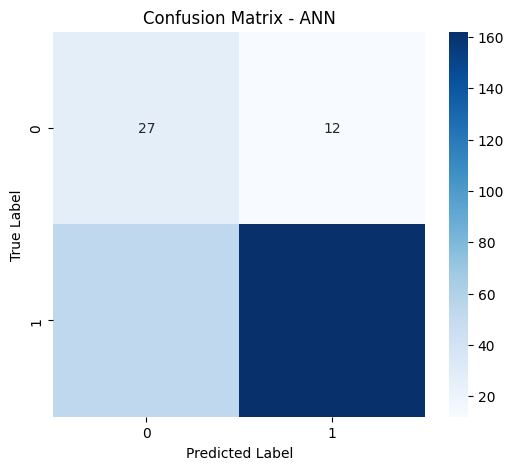

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7852 - loss: 0.5171
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8282 - loss: 0.4728
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8344 - loss: 0.4349
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8268 - loss: 0.4347
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8222 - loss: 0.4283
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8163 - loss: 0.4097
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8491 - loss: 0.3967
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8305 - loss: 0.3771
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8309 - loss: 0.3777
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8230 - loss: 0.3716
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8623 - loss: 0.3317
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8630 - loss: 0.2

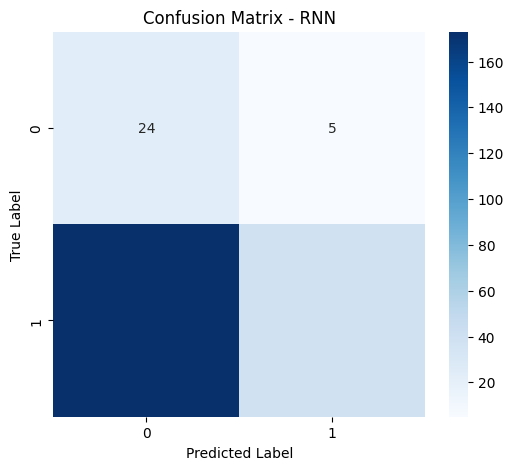

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7525 - loss: 0.5069 
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8444 - loss: 0.4164
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8468 - loss: 0.3993
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8415 - loss: 0.3770
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8313 - loss: 0.3861
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3778
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8509 - loss: 0.3290
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8385 - loss: 0.3569
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8503 - loss: 0.3138
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 0.3105
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8784 - loss: 0.2774
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8816 - loss: 0.2544

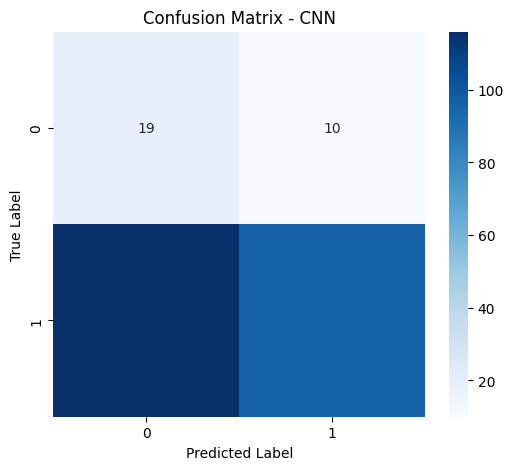

Epoch 1/50


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7603 - loss: 0.5797
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8407 - loss: 0.4431
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8334 - loss: 0.4443
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8349 - loss: 0.4301
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8411 - loss: 0.4126
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8294 - loss: 0.4297
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8578 - loss: 0.3874
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8541 - loss: 0.3904
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8482 - loss: 0.3838
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8359 - loss: 0.3886
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8450 - loss: 0.3844
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8661 - l

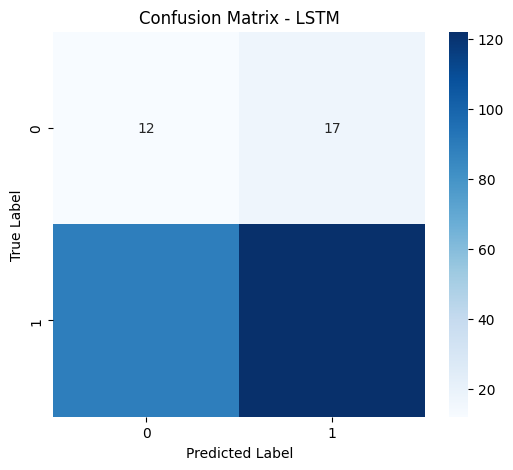


✅ Final Classification Model Evaluation Results:
  Model  Accuracy  Precision (1)  Recall (1)  F1-score (1)
0   ANN  0.744094       0.931034    0.753488      0.832905
1   RNN  0.258333       0.883721    0.180095      0.299213
2   CNN  0.475000       0.904762    0.450237      0.601266
3  LSTM  0.558333       0.877698    0.578199      0.697143
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


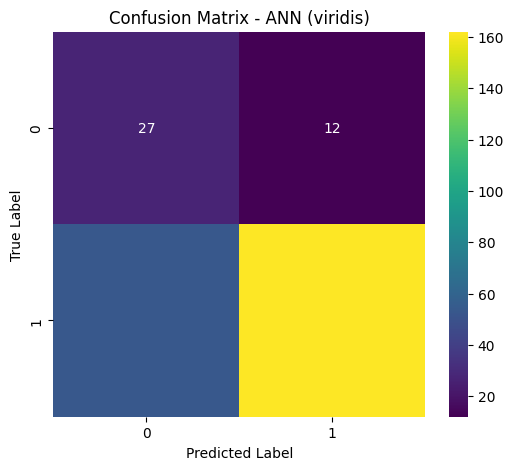

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("WS4.csv")

# Convert Date column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select features and classification target
features = ['weekday', 'quarter', 'is_working_day', 'Price', 'pct_price_day', 'scale_price',
            'n_customer_unique', 'n_invoice_unique', 'n_product_unique', 'season', 'waether',
            'n_customer_female', 'n_customer_male']
target = 'sales_situation'  # Classification target

# ✅ Encode target variable
label_encoder = LabelEncoder()
df[target] = label_encoder.fit_transform(df[target])  # Convert categorical to integer labels

# ✅ Scale features
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(df[features])
y = df[target].values

# ✅ Train-test split (80% train, 20% test)
split = int(len(df) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

# ✅ Define sequence length for RNN, CNN, LSTM
sequence_length = 14

# Function to create time sequences for RNN, CNN, LSTM
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i: i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

# ✅ Function to evaluate classification models
def evaluate_classification(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)  # Convert softmax probabilities to class labels

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=[str(cls) for cls in label_encoder.classes_], digits=4, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n📌 {model_name} Evaluation:")
    print(f"   ✅ Accuracy: {accuracy:.4f}")

    # Extract Precision, Recall, F1-score for Target = 1
    target_label = 1  # Target class
    precision_1 = report[str(target_label)]['precision']
    recall_1 = report[str(target_label)]['recall']
    f1_1 = report[str(target_label)]['f1-score']

    print("\nClassification Report for Target = 1:")
    print(f"   🔹 Precision: {precision_1:.4f}")
    print(f"   🔹 Recall: {recall_1:.4f}")
    print(f"   🔹 F1-score: {f1_1:.4f}")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(cls) for cls in label_encoder.classes_], yticklabels=[str(cls) for cls in label_encoder.classes_])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return accuracy, precision_1, recall_1, f1_1

# 🚀 ANN Model for Classification
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')  # Multi-class classification
])
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)
ann_accuracy, ann_precision, ann_recall, ann_f1 = evaluate_classification(ann_model, X_test, y_test, "ANN")

# 🚀 RNN Model for Classification
rnn_model = Sequential([
    SimpleRNN(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    SimpleRNN(50, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
rnn_accuracy, rnn_precision, rnn_recall, rnn_f1 = evaluate_classification(rnn_model, X_test_seq, y_test_seq, "RNN")

# 🚀 CNN Model for Classification
cnn_model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(sequence_length, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
cnn_accuracy, cnn_precision, cnn_recall, cnn_f1 = evaluate_classification(cnn_model, X_test_seq, y_test_seq, "CNN")

# 🚀 LSTM Model for Classification
lstm_model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, X_train.shape[1])),
    LSTM(50, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=1)
lstm_accuracy, lstm_precision, lstm_recall, lstm_f1 = evaluate_classification(lstm_model, X_test_seq, y_test_seq, "LSTM")

# ✅ Store Results in DataFrame
results_df = pd.DataFrame({
    "Model": ["ANN", "RNN", "CNN", "LSTM"],
    "Accuracy": [ann_accuracy, rnn_accuracy, cnn_accuracy, lstm_accuracy],
    "Precision (1)": [ann_precision, rnn_precision, cnn_precision, lstm_precision],
    "Recall (1)": [ann_recall, rnn_recall, cnn_recall, lstm_recall],
    "F1-score (1)": [ann_f1, rnn_f1, cnn_f1, lstm_f1]
})

print("\n✅ Final Classification Model Evaluation Results:")
print(results_df)

# ✅ Reprint ANN Confusion Matrix with 'viridis' color scheme
y_pred_prob_ann = ann_model.predict(X_test)
y_pred_ann = np.argmax(y_pred_prob_ann, axis=1)  # Convert softmax probabilities to class labels
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='viridis', xticklabels=[str(cls) for cls in label_encoder.classes_], yticklabels=[str(cls) for cls in label_encoder.classes_])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ANN (viridis)")
plt.show()


In [ ]:

print(matplotlib.__version__)


3.9.1


3.9.1


In [ ]:
df

,TotalSales,weekday,quarter,is_working_day,Price,pct_price_day,scale_price,n_customer_unique,n_invoice_unique,n_product_unique,season,waether,n_customer_female,n_customer_male,sales_situation
Date,,,,,,,,,,,,,,,
2019-01-02,26514,2,1,1,241,0.000000,0.160009,20,22,28,3,31,2,18,0
2019-01-03,21119,3,1,1,359,0.489627,0.464722,12,17,18,1,21,6,6,0
2019-01-04,16807,4,1,1,377,0.050139,0.142462,11,12,14,1,21,8,3,0
2019-01-05,15722,5,1,0,242,-0.358090,0.461641,12,12,10,3,27,9,3,0
2019-01-07,38985,0,1,1,396,0.636364,0.232311,18,23,23,2,24,11,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-21,104084,1,1,1,1142,0.004398,0.238813,13,14,18,2,16,13,0,1
2023-03-22,132997,2,1,1,814,-0.287215,0.199514,11,12,18,1,23,10,1,1
2023-03-23,80991,3,1,1,1719,1.111794,0.334025,7,9,12,2,16,7,0,1
